# BENDS synthetic example

This notebook runs **BENDS: Bayesian Estimation of Noisy Derivative Shifts** on the synthetic example segment.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

# Resolve the repository root whether the notebook is launched from
# the Python folder or from the repository root.
WORKING_DIR = Path.cwd()

if (WORKING_DIR / "example_data").exists():
    REPO_ROOT = WORKING_DIR
else:
    REPO_ROOT = WORKING_DIR.parent

PYTHON_DIR = REPO_ROOT / "Python"
sys.path.insert(0, str(PYTHON_DIR))

from bends import BENDS

## Load the synthetic segment

In [2]:
data = np.loadtxt(
    REPO_ROOT / "example_data" / "synthetic_segment.csv",
    delimiter=",",
    skiprows=1,
)

t = data[:, 0]
y = data[:, 1]

## BENDS settings

In [3]:
t_N = 35.0       # documented event time [min]
t_D = 20.0       # maximum timing uncertainty [min]
PreL = 15.0      # pre-candidate window length [min]
PostL = 15.0     # post-candidate window length [min]
tau = 0.05       # residual-fluctuation tolerance
q = +1           # expected shift toward a more positive slope

# Known slope-change time used only to evaluate the synthetic example.
c_true = 30.0

## Run BENDS

In [4]:
c_star, m1, m2, b1, b2 = BENDS(
    t, y, t_N, t_D, PreL, PostL, tau, q
)

print(f"c_star = {c_star:.6f} min")
print(f"m1     = {m1:.6f} signal units/min")
print(f"m2     = {m2:.6f} signal units/min")
print(f"b1     = {b1:.6f} signal units")
print(f"b2     = {b2:.6f} signal units")

c_star = 30.000000 min
m1     = -0.158598 signal units/min
m2     = 0.336260 signal units/min
b1     = 97.827318 signal units
b2     = 95.627363 signal units


## Plot the selected pre- and post-candidate fits

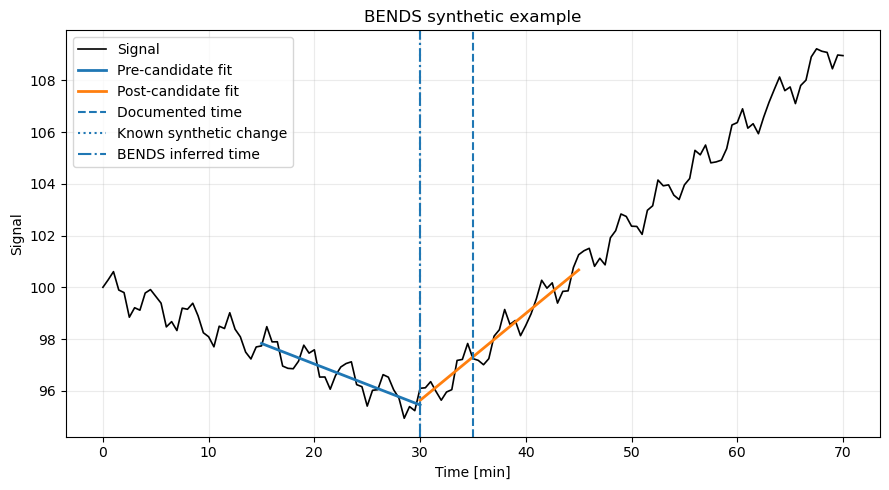

In [5]:
# Fitted lines at the selected candidate.
idx_pre = (t >= c_star - PreL) & (t <= c_star)
t_pre = t[idx_pre]
x_pre = t_pre - (c_star - PreL)
y_pre_fit = b1 + m1 * x_pre

idx_post = (t >= c_star) & (t <= c_star + PostL)
t_post = t[idx_post]
x_post = t_post - c_star
y_post_fit = b2 + m2 * x_post

plt.figure(figsize=(9, 5))
plt.plot(t, y, "k-", linewidth=1.2, label="Signal")
plt.plot(t_pre, y_pre_fit, linewidth=2, label="Pre-candidate fit")
plt.plot(t_post, y_post_fit, linewidth=2, label="Post-candidate fit")
plt.axvline(t_N, linestyle="--", label="Documented time")
plt.axvline(c_true, linestyle=":", label="Known synthetic change")
plt.axvline(c_star, linestyle="-.", label="BENDS inferred time")
plt.xlabel("Time [min]")
plt.ylabel("Signal")
plt.title("BENDS synthetic example")
plt.grid(True, alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()